<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_16_Frameworks_Deep_Learning_Professor_Resposta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 16 – Frameworks de Deep Learning  
## Deep Learning e Inteligência Artificial Generativa Aplicada

### Tema da aula
Configuração de ambiente e comparação prática entre frameworks de Deep Learning.

### Capacidades
- Utilizar frameworks de Deep Learning.

### Conhecimentos
- TensorFlow.
- PyTorch.
- Ecossistema de frameworks.

### Estratégia
Demonstração prática comparativa entre frameworks.

### Recursos
- TensorFlow.
- PyTorch.
- GPU.
- Google Colab.

### Critérios de avaliação
- Diferencia funcionalidades dos frameworks.
- Configura corretamente ambiente de desenvolvimento.
- Organiza dependências adequadamente.

### Evidência de aprendizagem
Ambiente configurado.


### Versão do Professor — com solução comentada

## 1. Contextualização da aula

Nas aulas anteriores, trabalhamos com NLP, vetorização, classificação textual, transformers, LLMs e engenharia de prompt.

A partir desta aula, o foco passa a ser a utilização prática de frameworks de Deep Learning.

Nesta aula, o estudante irá comparar **TensorFlow** e **PyTorch**, verificando:

- instalação/importação;
- versões das bibliotecas;
- disponibilidade de GPU;
- criação de tensores;
- operações básicas;
- construção de uma rede neural simples;
- organização de dependências;
- boas práticas de configuração de ambiente.

A evidência final será o ambiente configurado e validado.

## 2. TensorFlow e PyTorch — visão geral

### TensorFlow

O TensorFlow é um framework de Deep Learning criado pelo Google.  
Ele é bastante utilizado em produção, aplicações em nuvem, dispositivos móveis, pipelines escaláveis e modelos com Keras.

Pontos fortes:

- integração com Keras;
- bom ecossistema para produção;
- TensorFlow Lite para dispositivos embarcados/móveis;
- TensorFlow Serving para implantação;
- boa documentação para pipelines completos.

### PyTorch

O PyTorch é um framework de Deep Learning bastante usado em pesquisa, prototipagem e projetos modernos de IA.

Pontos fortes:

- sintaxe mais próxima do Python;
- facilidade para depuração;
- muito usado em pesquisa acadêmica;
- forte presença em modelos generativos, visão computacional e NLP;
- integração frequente com Hugging Face.

### Ideia central

Não existe “melhor framework” absoluto.  
A escolha depende do objetivo, da equipe, da infraestrutura, do tipo de projeto e do ecossistema utilizado.

## 3. Configuração do ambiente no Google Colab

No Google Colab, TensorFlow e PyTorch normalmente já vêm instalados.

Para verificar ou instalar manualmente, podem ser usados:

```python
!pip install tensorflow
!pip install torch torchvision torchaudio
```

Para usar GPU no Colab:

1. Acesse o menu **Ambiente de execução**.
2. Clique em **Alterar tipo de ambiente de execução**.
3. Em **Acelerador de hardware**, escolha **GPU**.
4. Salve e execute novamente as células.

Nesta aula, vamos criar testes para confirmar se o ambiente está configurado corretamente.

In [ ]:
# ============================================================
# 4. Importação de bibliotecas gerais
# ============================================================

import sys
import platform
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Sistema:", platform.platform())
print("Ambiente inicial carregado com sucesso.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Sistema: Linux-6.6.122+-x86_64-with-glibc2.35
Ambiente inicial carregado com sucesso.


## 5. Verificação de dependências instaladas

A célula abaixo verifica se TensorFlow e PyTorch estão disponíveis no ambiente.

Caso alguma biblioteca não esteja instalada, o notebook irá indicar o problema.

In [ ]:
# ============================================================
# Verificação de instalação do TensorFlow e PyTorch
# ============================================================

dependencias = {}

try:
    import tensorflow as tf
    dependencias["tensorflow"] = {
        "instalado": True,
        "versao": tf.__version__
    }
except Exception as e:
    dependencias["tensorflow"] = {
        "instalado": False,
        "erro": str(e)
    }

try:
    import torch
    dependencias["torch"] = {
        "instalado": True,
        "versao": torch.__version__
    }
except Exception as e:
    dependencias["torch"] = {
        "instalado": False,
        "erro": str(e)
    }

pd.DataFrame(dependencias).T

,instalado,versao
tensorflow,True,2.20.0
torch,True,2.11.0+cpu


## 6. Instalação opcional das bibliotecas

Execute esta célula apenas se alguma biblioteca não estiver instalada.

No Colab, em muitos casos, não será necessário executar.

In [ ]:
# ============================================================
# Instalação opcional
# ============================================================
# Execute apenas se necessário.

# !pip install -q tensorflow
# !pip install -q torch torchvision torchaudio

## 7. Verificação de GPU

A GPU acelera operações matemáticas usadas em Deep Learning.

Nem toda aula precisa de GPU, mas saber verificar sua disponibilidade é uma habilidade importante.

Vamos verificar a GPU em:

- TensorFlow;
- PyTorch.

In [ ]:
# ============================================================
# Verificação de GPU no TensorFlow e no PyTorch
# ============================================================

import tensorflow as tf
import torch

print("TensorFlow versão:", tf.__version__)
print("PyTorch versão:", torch.__version__)

print("\nGPUs detectadas pelo TensorFlow:")
print(tf.config.list_physical_devices('GPU'))

print("\nGPU disponível no PyTorch?")
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print("Nome da GPU:", torch.cuda.get_device_name(0))
else:
    print("Nenhuma GPU disponível para PyTorch neste ambiente.")

TensorFlow versão: 2.20.0
PyTorch versão: 2.11.0+cpu

GPUs detectadas pelo TensorFlow:
[]

GPU disponível no PyTorch?
False
Nenhuma GPU disponível para PyTorch neste ambiente.


## 8. Organização de dependências

Em projetos reais, é importante registrar as bibliotecas utilizadas.

Isso pode ser feito com um arquivo `requirements.txt`.

Exemplo:

```txt
tensorflow
torch
torchvision
torchaudio
pandas
numpy
matplotlib
scikit-learn
```

Também é possível fixar versões:

```txt
tensorflow==2.16.1
torch==2.3.0
pandas==2.2.2
```

Fixar versões ajuda a reproduzir o ambiente, mas pode gerar conflitos se a versão do Python ou do sistema não for compatível.

In [ ]:
# Criando um requirements.txt didático

requirements = '''
tensorflow
torch
torchvision
torchaudio
pandas
numpy
matplotlib
scikit-learn
'''.strip()

with open("requirements_aula16.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print(requirements)
print("\nArquivo requirements_aula16.txt criado com sucesso.")

tensorflow
torch
torchvision
torchaudio
pandas
numpy
matplotlib
scikit-learn

Arquivo requirements_aula16.txt criado com sucesso.


## 9. Tensores no TensorFlow

Tensores são estruturas de dados fundamentais em Deep Learning.

Podemos pensar em tensores como generalizações de:

- escalares;
- vetores;
- matrizes;
- arrays multidimensionais.

Vamos criar tensores simples com TensorFlow.

In [ ]:
# ============================================================
# Tensores com TensorFlow
# ============================================================

tensor_tf = tf.constant([[1, 2, 3], [4, 5, 6]], dtype=tf.float32)

print("Tensor TensorFlow:")
print(tensor_tf)

print("\nFormato:")
print(tensor_tf.shape)

print("\nTipo:")
print(tensor_tf.dtype)

Tensor TensorFlow:
tf.Tensor(
[[1. 2. 3.]
 [4. 5. 6.]], shape=(2, 3), dtype=float32)

Formato:
(2, 3)

Tipo:
<dtype: 'float32'>


In [ ]:
# Operações básicas com TensorFlow

a_tf = tf.constant([[1, 2], [3, 4]], dtype=tf.float32)
b_tf = tf.constant([[10, 20], [30, 40]], dtype=tf.float32)

soma_tf = a_tf + b_tf
multiplicacao_tf = tf.matmul(a_tf, b_tf)

print("Soma:")
print(soma_tf)

print("\nMultiplicação matricial:")
print(multiplicacao_tf)

Soma:
tf.Tensor(
[[11. 22.]
 [33. 44.]], shape=(2, 2), dtype=float32)

Multiplicação matricial:
tf.Tensor(
[[ 70. 100.]
 [150. 220.]], shape=(2, 2), dtype=float32)


## 10. Tensores no PyTorch

Agora vamos fazer operações equivalentes usando PyTorch.

In [ ]:
# ============================================================
# Tensores com PyTorch
# ============================================================

tensor_torch = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)

print("Tensor PyTorch:")
print(tensor_torch)

print("\nFormato:")
print(tensor_torch.shape)

print("\nTipo:")
print(tensor_torch.dtype)

Tensor PyTorch:
tensor([[1., 2., 3.],
        [4., 5., 6.]])

Formato:
torch.Size([2, 3])

Tipo:
torch.float32


In [ ]:
# Operações básicas com PyTorch

a_torch = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
b_torch = torch.tensor([[10, 20], [30, 40]], dtype=torch.float32)

soma_torch = a_torch + b_torch
multiplicacao_torch = torch.matmul(a_torch, b_torch)

print("Soma:")
print(soma_torch)

print("\nMultiplicação matricial:")
print(multiplicacao_torch)

Soma:
tensor([[11., 22.],
        [33., 44.]])

Multiplicação matricial:
tensor([[ 70., 100.],
        [150., 220.]])


## 11. Comparação didática entre TensorFlow e PyTorch

| Aspecto | TensorFlow | PyTorch |
|---|---|---|
| Origem | Google | Meta/Facebook AI |
| Interface comum | Keras | torch.nn |
| Uso frequente | Produção, mobile, nuvem | Pesquisa, prototipagem, IA moderna |
| Depuração | Boa, mas historicamente menos direta | Muito próxima do Python |
| Implantação | TensorFlow Serving, TensorFlow Lite | TorchScript, ONNX, ecossistema externo |
| Curva de aprendizado | Acessível com Keras | Acessível para quem conhece Python |
| Uso em NLP moderno | Presente | Muito forte com Hugging Face |

Na prática, o profissional deve conhecer os dois, pois muitos projetos, bibliotecas e modelos já vêm prontos em um framework específico.

## 12. Dataset didático para comparação prática

Vamos criar um dataset simples de classificação binária.

A ideia é prever uma classe com base em duas variáveis numéricas.

Esse exemplo é simples de propósito, pois o foco da aula é comparar o uso dos frameworks e configurar o ambiente.

In [ ]:
# ============================================================
# Criação de dataset sintético
# ============================================================

np.random.seed(42)

n = 600

x1_classe0 = np.random.normal(loc=1.5, scale=0.6, size=n//2)
x2_classe0 = np.random.normal(loc=1.5, scale=0.6, size=n//2)

x1_classe1 = np.random.normal(loc=3.5, scale=0.6, size=n//2)
x2_classe1 = np.random.normal(loc=3.5, scale=0.6, size=n//2)

X0 = np.column_stack([x1_classe0, x2_classe0])
X1 = np.column_stack([x1_classe1, x2_classe1])

X = np.vstack([X0, X1]).astype("float32")
y = np.array([0]*(n//2) + [1]*(n//2)).astype("float32")

indices = np.random.permutation(n)
X = X[indices]
y = y[indices]

df_dados = pd.DataFrame(X, columns=["variavel_1", "variavel_2"])
df_dados["classe"] = y.astype(int)

df_dados.head()

,variavel_1,variavel_2,classe
0,1.789483,1.622078,0
1,4.223906,3.634348,1
2,1.972251,1.521158,0
3,3.757771,3.457039,1
4,2.181340,1.469857,0


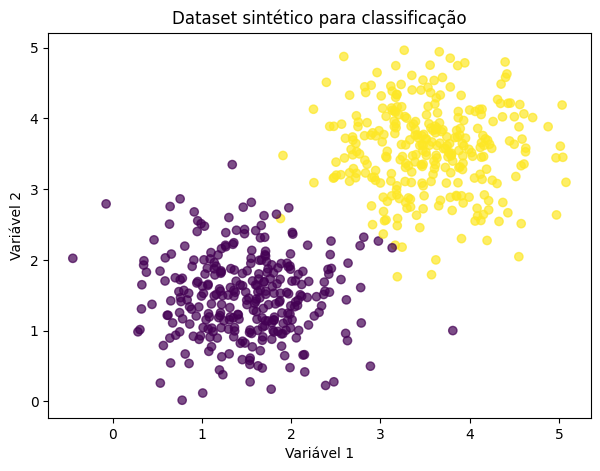

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(df_dados["variavel_1"], df_dados["variavel_2"], c=df_dados["classe"], alpha=0.7)
plt.title("Dataset sintético para classificação")
plt.xlabel("Variável 1")
plt.ylabel("Variável 2")
plt.show()

## 13. Modelo simples com TensorFlow/Keras

Vamos criar uma pequena rede neural com Keras.

Fluxo básico:

1. definir modelo;
2. compilar;
3. treinar;
4. avaliar;
5. gerar predições.

In [ ]:
# ============================================================
# Modelo com TensorFlow/Keras
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

modelo_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

modelo_tf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

historico_tf = modelo_tf.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    verbose=0,
    validation_split=0.2
)

avaliacao_tf = modelo_tf.evaluate(X_test, y_test, verbose=0)

print("Loss TensorFlow:", round(avaliacao_tf[0], 4))
print("Acurácia TensorFlow:", round(avaliacao_tf[1], 4))

Loss TensorFlow: 0.5625
Acurácia TensorFlow: 0.64


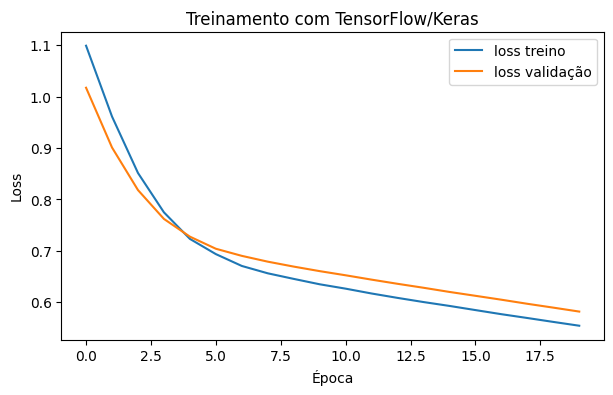

In [ ]:
# Curva de treinamento TensorFlow

plt.figure(figsize=(7, 4))
plt.plot(historico_tf.history["loss"], label="loss treino")
plt.plot(historico_tf.history["val_loss"], label="loss validação")
plt.title("Treinamento com TensorFlow/Keras")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 14. Modelo simples com PyTorch

Agora vamos criar uma rede neural equivalente usando PyTorch.

No PyTorch, normalmente escrevemos mais etapas manualmente:

1. converter dados para tensores;
2. definir classe do modelo;
3. definir função de perda;
4. definir otimizador;
5. criar loop de treinamento;
6. avaliar.

In [ ]:
# ============================================================
# Modelo com PyTorch
# ============================================================

import torch.nn as nn
import torch.optim as optim

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

class RedeSimplesTorch(nn.Module):
    def __init__(self):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.rede(x)

modelo_torch = RedeSimplesTorch()

criterio = nn.BCELoss()
otimizador = optim.Adam(modelo_torch.parameters(), lr=0.01)

perdas_torch = []

for epoca in range(20):
    modelo_torch.train()

    pred = modelo_torch(X_train_t)
    perda = criterio(pred, y_train_t)

    otimizador.zero_grad()
    perda.backward()
    otimizador.step()

    perdas_torch.append(perda.item())

modelo_torch.eval()
with torch.no_grad():
    pred_test = modelo_torch(X_test_t)
    pred_classes = (pred_test.numpy() >= 0.5).astype(int).flatten()
    acc_torch = accuracy_score(y_test, pred_classes)

print("Loss final PyTorch:", round(perdas_torch[-1], 4))
print("Acurácia PyTorch:", round(acc_torch, 4))

Loss final PyTorch: 0.6593
Acurácia PyTorch: 0.7067


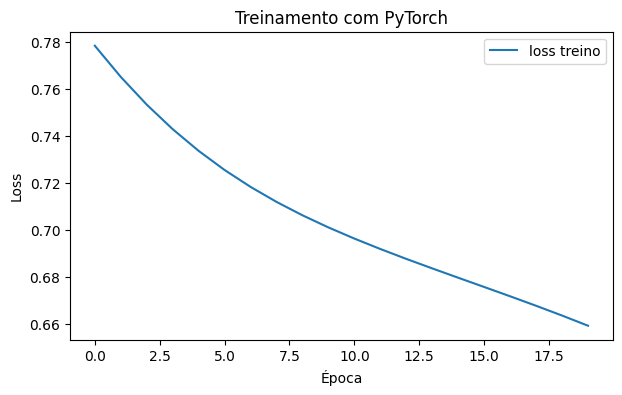

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(perdas_torch, label="loss treino")
plt.title("Treinamento com PyTorch")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 15. Comparação dos resultados

Agora vamos comparar os frameworks em relação ao uso nesta atividade.

In [ ]:
comparacao = pd.DataFrame({
    "framework": ["TensorFlow/Keras", "PyTorch"],
    "estilo": [
        "Mais alto nível com Keras; treino com model.fit",
        "Mais explícito; treino com loop manual"
    ],
    "acuracia_teste": [
        round(float(avaliacao_tf[1]), 4),
        round(float(acc_torch), 4)
    ],
    "observacao": [
        "Mais direto para iniciantes e prototipagem rápida com Keras",
        "Mais flexível e transparente para personalização do treino"
    ]
})

comparacao

,framework,estilo,acuracia_teste,observacao
0,TensorFlow/Keras,Mais alto nível com Keras; treino com model.fit,0.6400,Mais direto para iniciantes e prototipagem ráp...
1,PyTorch,Mais explícito; treino com loop manual,0.7067,Mais flexível e transparente para personalizaç...


## 16. Checklist de ambiente configurado

A evidência de aprendizagem desta aula é o ambiente configurado.

O estudante deve demonstrar que:

- TensorFlow foi importado corretamente;
- PyTorch foi importado corretamente;
- as versões foram identificadas;
- GPU foi verificada;
- dependências foram organizadas;
- tensores foram criados nos dois frameworks;
- um modelo simples foi executado em pelo menos um framework;
- preferencialmente, os dois frameworks foram testados.

In [ ]:
checklist_ambiente = {
    "python_verificado": True,
    "tensorflow_importado": dependencias["tensorflow"]["instalado"],
    "pytorch_importado": dependencias["torch"]["instalado"],
    "versao_tensorflow": dependencias["tensorflow"].get("versao", "não instalado"),
    "versao_pytorch": dependencias["torch"].get("versao", "não instalado"),
    "gpu_tensorflow_verificada": True,
    "gpu_pytorch_verificada": True,
    "requirements_criado": True,
    "tensor_tensorflow_criado": True,
    "tensor_pytorch_criado": True,
    "modelo_tensorflow_treinado": True,
    "modelo_pytorch_treinado": True
}

pd.DataFrame([checklist_ambiente]).T.rename(columns={0: "status"})

,status
python_verificado,True
tensorflow_importado,True
pytorch_importado,True
versao_tensorflow,2.20.0
versao_pytorch,2.11.0+cpu
gpu_tensorflow_verificada,True
gpu_pytorch_verificada,True
requirements_criado,True
tensor_tensorflow_criado,True
tensor_pytorch_criado,True


## 17. Atividade prática avaliativa

### Desafio

Você deverá validar o ambiente de desenvolvimento para Deep Learning.

### Entregas esperadas

1. Verificar versão do Python.
2. Verificar instalação do TensorFlow.
3. Verificar instalação do PyTorch.
4. Verificar disponibilidade de GPU.
5. Criar um arquivo `requirements.txt`.
6. Criar tensores nos dois frameworks.
7. Executar operações básicas nos dois frameworks.
8. Treinar ou executar uma rede neural simples.
9. Comparar TensorFlow e PyTorch.
10. Apresentar um checklist final de ambiente configurado.

## 18. Questões para reflexão

1. Qual é a principal diferença de uso entre TensorFlow/Keras e PyTorch nesta aula?

A principal diferença entre TensorFlow/Keras e PyTorch, nesta aula, está na forma de uso e no nível de abstração.
O TensorFlow/Keras oferece uma abordagem mais simples e de alto nível, facilitando a criação de modelos de forma rápida e estruturada.
Já o PyTorch possui uma abordagem mais flexível e dinâmica, permitindo maior controle sobre o código e o treinamento do modelo.

2. Em que tipo de projeto TensorFlow pode ser uma boa escolha?
O TensorFlow é uma boa escolha para projetos que exigem escalabilidade e implantação em produção.
Ele é amplamente utilizado em aplicações empresariais, especialmente quando há necessidade de integração com sistemas, APIs e execução em diferentes ambientes (cloud, mobile e servidor).
Também é indicado para projetos que demandam treinamento e inferência em larga escala.
Além disso, possui suporte robusto para deploy com TensorFlow Serving e TensorFlow Lite.

3. Em que tipo de projeto PyTorch pode ser uma boa escolha?

O PyTorch é uma boa escolha para projetos que exigem flexibilidade e experimentação, sendo muito utilizado em pesquisa e desenvolvimento.
Ele permite maior controle sobre o modelo e o processo de treinamento.
Sua execução dinâmica facilita testes, ajustes e depuração do código.
É ideal para projetos que envolvem prototipagem rápida e modelos personalizados.

4. Por que é importante verificar a GPU antes de treinar modelos maiores?

Verificar a GPU antes de treinar modelos maiores é importante para garantir desempenho e viabilidade do treinamento.
Modelos de deep learning exigem alto poder computacional e podem ser muito lentos sem GPU.
A GPU acelera operações matemáticas intensivas, como multiplicação de matrizes.
Também é necessário verificar a memória disponível (VRAM), pois modelos grandes podem não caber na GPU.
Além disso, confirma se o ambiente está corretamente configurado (CUDA, drivers, etc.).Verificar a GPU antes de treinar modelos maiores é importante para garantir desempenho e viabilidade do treinamento.
Modelos de deep learning exigem alto poder computacional e podem ser muito lentos sem GPU.
A GPU acelera operações matemáticas intensivas, como multiplicação de matrizes.
Também é necessário verificar a memória disponível (VRAM), pois modelos grandes podem não caber na GPU.
Além disso, confirma se o ambiente está corretamente configurado (CUDA, drivers, etc.).

5. Por que organizar dependências em um `requirements.txt` ajuda no trabalho profissional?

In [ ]:
# Respostas esperadas - versão professor

respostas = {
    "1": "TensorFlow/Keras oferece uma API mais direta com model.fit; PyTorch exige um loop de treino mais explícito, oferecendo maior controle.",
    "2": "Projetos de produção, aplicações com TensorFlow Lite, deploy em nuvem e fluxos integrados ao ecossistema TensorFlow.",
    "3": "Pesquisa, prototipagem, modelos customizados, NLP moderno e uso frequente com Hugging Face.",
    "4": "Porque GPU acelera operações de treino e evita que modelos grandes demorem excessivamente.",
    "5": "Porque registra dependências, facilita reprodução do ambiente e reduz problemas de instalação em outros computadores."
}

for k, v in respostas.items():
    print(f"{k}. {v}\n")

1. TensorFlow/Keras oferece uma API mais direta com model.fit; PyTorch exige um loop de treino mais explícito, oferecendo maior controle.

2. Projetos de produção, aplicações com TensorFlow Lite, deploy em nuvem e fluxos integrados ao ecossistema TensorFlow.

3. Pesquisa, prototipagem, modelos customizados, NLP moderno e uso frequente com Hugging Face.

4. Porque GPU acelera operações de treino e evita que modelos grandes demorem excessivamente.

5. Porque registra dependências, facilita reprodução do ambiente e reduz problemas de instalação em outros computadores.



## 19. Critérios de avaliação

| Critério | Atingiu | Não atingiu |
|---|---|---|
| Diferencia funcionalidades dos frameworks | Compara TensorFlow e PyTorch considerando uso, estilo e aplicações | Não identifica diferenças relevantes |
| Configura corretamente ambiente | Verifica Python, bibliotecas, versões e GPU | Não valida o ambiente ou ignora erros |
| Organiza dependências adequadamente | Cria ou interpreta `requirements.txt` | Não registra dependências |
| Executa operações básicas | Cria tensores e operações nos dois frameworks | Não consegue manipular tensores |
| Executa demonstração prática | Treina ou testa modelo simples | Não executa exemplo funcional |
| Interpreta resultados | Compara desempenho, estrutura e facilidade de uso | Apenas executa código sem análise |

## Encerramento

Nesta aula, o estudante configurou e validou um ambiente de desenvolvimento para Deep Learning, comparando TensorFlow e PyTorch por meio de exemplos práticos.

A evidência de aprendizagem é o **ambiente configurado**, comprovado por versões, GPU, dependências, operações com tensores e execução de modelo simples.